# Assessing the Predictive Power of Socio-Economic and Demographic Indicators for Ward-Level Crime Rates in London

## Preparation

- [Github link](https://github.com/Iriszhew/CASA0006-coursework)

- Number of words: 1499

- Runtime: 2.09mins (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker, JupyterLab, Python 3

-  License: this notebook is made available under the Creative Commons Attribution license.

- Additional libraries: None beyond the standard Python data science libraries used in the module.

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results](#Results)

1. [Discussion](#Discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

1. [Appendix](#Appendix)

## 1.0 Introduction

[[ go back to the top ]](#Table-of-contents)

Crime affects the well-being of citizens in today's major cities and causes significant economic and social losses (Cheng and Williams, 2012). As a global city and a centre for international trade, finance and culture, London's scale and international character present complex challenges for crime governance (Ashby et al., 2022). As of January 2026, London's overall crime rate stood at 83 offences per 1,000 people, which is higher than the average for England and approximately 1.14 times the national average (Crimerate, 2026). This indicates that crime remains a key issue in London's urban governance.

Previous research has shown a close link between crime and socioeconomic factors. Factors such as unemployment rates, levels of inequality, educational attainment, income levels, immigration rates, and family structure are considered potential contributors to crime (Tarling and Dennis, 2016; Pramsten, 2025; Hjalmarsson, Machin, and Pinotti,
2024). Relatively low socioeconomic status reduces collective efficacy and weakens social control, thereby contributing to the occurrence of criminal incidents such as neighborhood violence (Zhou, Wang, and Zhou, 2023). Additionally, population density, gender, and age structure serve as key demographic indicators in studies examining the factors influencing crime rates (Pramsten,
2025). Therefore, researching the relevant socioeconomic factors that influence criminal incidents is crucial, as it can assist policymakers in developing targeted and effective interventions.

Previous research has indicated a correlation between crime rates and socioeconomic factors, but many studies rely on linear regression models to analyze these relationships. While linear models offer strong interpretability, they may struggle to fully capture nonlinear relationships and complex interactions among variables (Pramsten, 2025; Tarling and Dennis, 2016). Therefore, this paper uses London wards as the unit of analysis to examine the extent to which socioeconomic and demographic indicators can predict crime rates and to identify the variables that contribute most significantly to these predictions.


### 1.1 Requirements to run the analysis

[[ go back to the top ]](#Table-of-contents)


In [2]:
# Basic data handling
import pandas as pd
import numpy as np
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# Spatial data processing
import geopandas as gpd
# Model training and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Model interpretation
from sklearn.inspection import permutation_importance
import shap

## 2. Research questions

[[ go back to the top ]](#Table-of-contents)

This study asks the following research question:

**To what extent can socio-economic and demographic indicators predict ward-level crime rates in London?**

To answer this question, the analysis addresses two sub-questions:

1. How well do the selected socio-economic and demographic indicators predict ward-level crime rates when using Linear Regression and Random Forest models?

2. Which indicators contribute most to the Random Forest model’s predictions of ward-level crime rates?

## 3. Data

[[ go back to the top ]](#Table-of-contents)



### 3.1 Data sources and variables

| Variable / Data | Type | Description | Source / Link |
|---|---|---|---|
| Crime rate per 1,000 residents | Numeric | Number of recorded crimes per 1,000 residents in each ward, calculated using total recorded crimes from April 2022 to March 2023 and the 2021 usual resident population (`crime_rate_1000`). | [MPS Recorded Crime Geographic Breakdown](https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m/) |
| Young population share | Numeric | Percentage of residents aged 20–39 in each ward. (`young_adult_share_2021`)| [2021 Ward and LSOA Census Estimates](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/) |
| Population density | Numeric | Number of usual residents per square kilometre in each ward, calculated by dividing the 2021 usual resident population by ward area (`pop_density_2021`). | [2021 Ward and LSOA Census Estimates](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/); [Wards December 2022 Boundaries UK BGC](https://ckan.publishing.service.gov.uk/dataset/wards-december-2022-boundaries-uk-bgc1/resource/ea52d049-9c61-4296-8341-9dd89fb253b3?inner_span=True) |
| Higher education share | Numeric |Percentage of usual residents aged 16 and over with Level 4 or above qualifications in each ward (`higher_education_share_2021`). | [2021 Ward and LSOA Census Estimates](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/) |
| Lone-parent household share | Numeric | Percentage of households that are lone-parent households with dependent or non-dependent children in each ward (`lone_parent_household_share_2021`). | [2021 Ward and LSOA Census Estimates](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/) |
|Severe household deprivation share | Numeric | Percentage of households deprived in two or more dimensions in each ward (`severe_household_deprivation_share_2021`). | [2021 Ward and LSOA Census Estimates](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/) |
| Non-UK-born population share | Numeric | Percentage of usual residents born outside the United Kingdom in each ward (`non_uk_born_share_2021`). | [2021 Ward and LSOA Census Estimates](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/) |
| Unemployment rate | Numeric | Percentage of economically active residents who are unemployed in each ward (`unemployment_rate_2021`). | [2021 Ward and LSOA Census Estimates](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/) |
| Ward boundary data | Spatial / GeoJSON | Auxiliary spatial dataset used to calculate ward area; not included as an independent variable in the models.| [Wards December 2022 Boundaries UK BGC](https://ckan.publishing.service.gov.uk/dataset/wards-december-2022-boundaries-uk-bgc1/resource/ea52d049-9c61-4296-8341-9dd89fb253b3?inner_span=True) |

### 3.2 Data preparation summary

[[ go back to the top ]](#Table-of-contents)

The final dataset was created by summing April 2022–March 2023 MPS ward-level crime counts, joining them with 2021 Census variables, and adding boundary-derived area and population density measures. The 2022–2023 crime period was selected to reduce COVID-19 effects, while the 2021 Census provided the closest ward-level socio-economic data. The complete data preparation workflow is provided in the [`data_preparation.ipynb` notebook](https://github.com/Iriszhew/CASA0006-coursework/blob/main/data_preparation.ipynb), and the raw datasets are stored in the same GitHub repository.


In [3]:
# Read the final ward-level modelling dataset from GitHub 
url = "https://raw.githubusercontent.com/Iriszhew/CASA0006-coursework/refs/heads/main/model_df.csv"
model_df = pd.read_csv(url)
model_df.head()

,WardCode,WardName,crime_2022_23,population_2021,area_km2,pop_density_2021,crime_rate_1000,young_adult_share_2021,unemployment_rate_2021,higher_education_share_2021,non_uk_born_share_2021,lone_parent_household_share_2021,severe_household_deprivation_share_2021
0,E05009317,Bethnal Green,2480,21229,1.209060,17558.27,116.82,42.79,7.12,44.70,41.56,13.35,26.50
1,E05009318,Blackwall & Cubitt Town,1568,21834,1.352481,16143.67,71.81,57.44,6.59,62.72,56.55,7.66,13.71
2,E05009319,Bow East,1984,19530,1.868294,10453.38,101.59,50.32,6.72,54.30,36.07,11.58,20.99
3,E05009320,Bow West,1433,13708,1.358428,10091.07,104.54,44.24,5.18,52.26,35.20,10.47,22.46
4,E05009321,Bromley North,1131,11429,0.600027,19047.46,98.96,43.48,8.95,43.15,43.98,13.64,26.67


### 3.3 Exploratory Data Analysis

This section provides a brief exploratory analysis of the final modelling dataset, including missing values, summary statistics and the distribution of the dependent variable.

#### 3.3.1 Missing values and summary statistics

In [4]:
# Check missing values in the final modelling dataset
model_df.isna().sum()

WardCode                                   0
WardName                                   0
crime_2022_23                              0
population_2021                            0
area_km2                                   0
pop_density_2021                           0
crime_rate_1000                            0
young_adult_share_2021                     0
unemployment_rate_2021                     0
higher_education_share_2021                0
non_uk_born_share_2021                     0
lone_parent_household_share_2021           0
severe_household_deprivation_share_2021    0
dtype: int64

#### 3.3.2 Distribution and outlier inspection

In [5]:
# Select variables for EDA
eda_cols = [
    "crime_rate_1000",
    "pop_density_2021",
    "young_adult_share_2021",
    "unemployment_rate_2021",
    "higher_education_share_2021",
    "non_uk_born_share_2021",
    "lone_parent_household_share_2021",
    "severe_household_deprivation_share_2021"
]

# Summary statistics
model_df[eda_cols].describe().round(2)

,crime_rate_1000,pop_density_2021,young_adult_share_2021,unemployment_rate_2021,higher_education_share_2021,non_uk_born_share_2021,lone_parent_household_share_2021,severe_household_deprivation_share_2021
count,679.00,679.00,679.00,679.00,679.00,679.00,679.00,679.00
mean,99.58,8709.88,33.18,6.16,47.13,40.50,13.19,19.03
std,148.85,4856.63,8.38,1.58,12.10,12.13,4.35,6.05
min,26.49,163.59,15.35,2.83,24.25,6.45,4.19,6.28
25%,60.93,4953.24,27.02,4.89,37.00,32.85,10.01,14.16
50%,77.11,7755.42,31.25,6.03,46.11,41.04,12.60,18.73
75%,101.70,11767.10,38.93,7.26,56.60,49.06,15.80,23.48
max,3002.85,26256.64,64.07,12.27,75.67,72.35,30.22,40.29


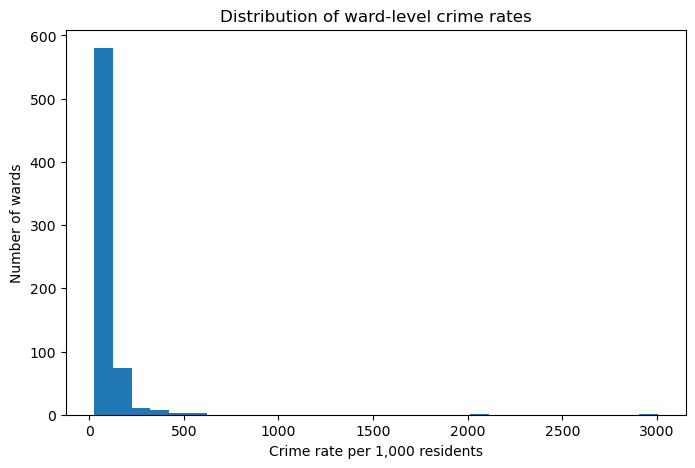

In [6]:
# Plot crime rate distribution
plt.figure(figsize=(8, 5))
plt.hist(model_df["crime_rate_1000"], bins=30)
plt.xlabel("Crime rate per 1,000 residents")
plt.ylabel("Number of wards")
plt.title("Distribution of ward-level crime rates")
plt.show()

The distribution is strongly right-skewed, suggesting the presence of a small number of extreme high-crime wards. The wards with the highest crime rates are inspected below.

In [7]:
# Inspect wards with the highest crime rates
model_df.sort_values("crime_rate_1000", ascending=False)[
    ["WardCode", "WardName", "crime_2022_23", "population_2021", "crime_rate_1000"]
].head(10)

,WardCode,WardName,crime_2022_23,population_2021,crime_rate_1000
461,E05013808,West End,33770,11246,3002.85
459,E05013806,St James's,21187,10076,2102.72
306,E05013653,Bloomsbury,6481,11367,570.16
315,E05013662,Holborn & Covent Garden,5558,10324,538.36
308,E05013655,Camden Town,3515,6810,516.15
677,E05014118,Waterloo & South Bank,4027,8881,453.44
401,E05013748,Shepherd's Bush Green,2534,5623,450.65
59,E05011095,Borough & Bankside,3481,9331,373.06
223,E05013570,Heathrow Villages,5232,14033,372.84
612,E05014053,Abbey,1465,3965,369.48


West End and St James’s have much higher crime rates than other wards. These areas have high recorded crime counts but relatively small resident populations, and the crime rate calculation does not capture visitors, commuters or tourists. Therefore, they were removed before modelling to reduce their disproportionate influence on the results.

In [8]:
# Remove two extreme outlier wards identified from the crime rate distribution
outlier_wards = ["West End", "St James's"]
model_df = model_df[
    ~model_df["WardName"].isin(outlier_wards)].copy()
model_df = model_df.reset_index(drop=True)

After removing the two most extreme wards, a log transformation was applied to the crime rate to further reduce the influence of skewness before regression modelling.

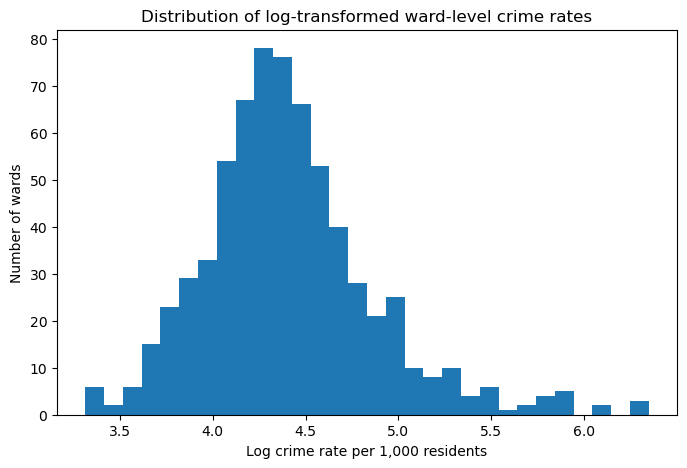

In [9]:
# Create log-transformed crime rate
model_df["log_crime_rate_1000"] = np.log1p(model_df["crime_rate_1000"])

# Plot log crime rate distribution
plt.figure(figsize=(8, 5))
plt.hist(model_df["log_crime_rate_1000"], bins=30)
plt.xlabel("Log crime rate per 1,000 residents")
plt.ylabel("Number of wards")
plt.title("Distribution of log-transformed ward-level crime rates")
plt.show()

#### 3.3.3 Correlation analysis

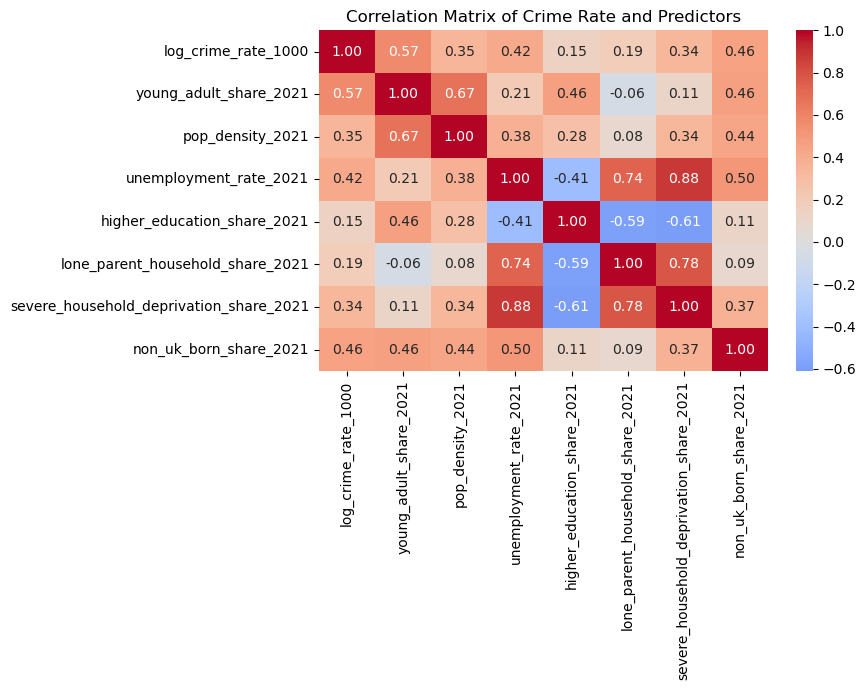

In [10]:
# correlation metrix
corr_cols = [
    'log_crime_rate_1000',
    'young_adult_share_2021',
    'pop_density_2021',
    'unemployment_rate_2021',
    'higher_education_share_2021',
    'lone_parent_household_share_2021',
    'severe_household_deprivation_share_2021',
    'non_uk_born_share_2021'
]

corr_matrix = model_df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Crime Rate and Predictors")
plt.tight_layout()
plt.show()

The correlation matrix shows that log-transformed crime rate is most strongly associated with young adult share, followed by non-UK-born population share and unemployment rate. Several predictors are also highly correlated with each other, especially unemployment rate and severe household deprivation, suggesting that some socio-economic disadvantage variables may overlap in what they measure.

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

This study employs supervised learning methods to predict crime rates at the London ward level using selected socioeconomic and demographic variables. First, linear regression is used as a baseline model to determine whether the selected variables can explain crime rates through a roughly linear relationship. It also serves as a benchmark against which the performance of the main model can be evaluated.

This study employs random forest regression as the main predictive model. Random forests are a nonparametric ensemble machine learning algorithm that can handle large numbers of potentially correlated predictors and detect nonlinear relationships and interaction effects without requiring strong assumptions (Pramsten, 2025). The flexibility and robustness of random forest models make them well-suited for analyzing the relationship between socioeconomic conditions and crime rates across London’s wards.

The Random Forest model was tuned using GridSearchCV with cross-validation on the training set to improve overall model accuracy. After model training, R-squared, MAE, and RMSE were calculated on the test set to evaluate the model’s interpretability and prediction error. Finally, this study used permutation importance and SHAP to interpret the model results, with the former identifying the variables most critical to predictive performance and the latter further analyzing the direction and extent of these variables’ influence on the prediction results.





### 4.1 Modelling setup

In [11]:
# Define target variable
y = model_df["log_crime_rate_1000"]

# Define explanatory variables
feature_cols = [
    "pop_density_2021",
    "young_adult_share_2021",
    "unemployment_rate_2021",
    "higher_education_share_2021",
    "non_uk_born_share_2021",
    "lone_parent_household_share_2021",
    "severe_household_deprivation_share_2021"
]

X = model_df[feature_cols]

In [12]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

### 4.2 Baseline model: Linear Regression

In [13]:
# Create and train linear regression model
lr = LinearRegression()
# Fit the model using training data
lr.fit(X_train, y_train)
# Predict crime rates for the test set
y_pred_lr = lr.predict(X_test)

In [14]:
# Evaluate model performance
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
# Predict on training set
y_train_pred_lr = lr.predict(X_train)
# Evaluate training performance
train_r2 = r2_score(y_train, y_train_pred_lr)
train_mae = mean_absolute_error(y_train, y_train_pred_lr)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))

In [15]:
# Store Linear Regression results in a table
lr_results = pd.DataFrame({
    "Model": ["Linear Regression", "Linear Regression"],
    "Dataset": ["Training", "Testing"],
    "R-squared": [train_r2, r2],
    "MAE": [train_mae, mae],
    "RMSE": [train_rmse, rmse]
}).round(3)

lr_results

,Model,Dataset,R-squared,MAE,RMSE
0,Linear Regression,Training,0.467,0.250,0.349
1,Linear Regression,Testing,0.478,0.231,0.292


### 4.3 Random Forest Regression and hyperparameter tuning


Random Forest Regression was tuned using GridSearchCV with 5-fold cross-validation on the training set, using R-squared as the scoring metric. To reduce overfitting, the parameter grid included relatively shallow tree depths and minimum leaf/split constraints. After identifying the best hyperparameters, the final Random Forest model was retrained on the training set and evaluated using the same metrics as the baseline model.

In [16]:
# Parameter grid for Random Forest tuning
param_grid = {
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [5, 8, 10, 15, 20],
    "min_samples_split": [10, 15, 20, 30],
    "max_features": ["sqrt", 0.5]
}
grid = GridSearchCV(
    estimator=RandomForestRegressor(
        n_estimators=400,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)
grid.fit(X_train, y_train)
print("Best hyperparameters:", grid.best_params_)
print("Best CV R-squared:", round(grid.best_score_, 3))

Best hyperparameters: {'max_depth': 7, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV R-squared: 0.455


The final Random Forest model was retrained with the best hyperparameters and evaluated using the same metrics.

In [17]:
# Retrain Random Forest with optimal hyperparameters
best_params = grid.best_params_
# Train the final Random Forest model using the best hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    **best_params
)
rf_model.fit(X_train, y_train)
# Predict on training and testing data
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
# Evaluate training performance
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
# Evaluate testing performance
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

In [18]:
# Store Random Forest results in a table
rf_results = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest"],
    "Dataset": ["Training", "Testing"],
    "R-squared": [rf_train_r2, rf_test_r2],
    "MAE": [rf_train_mae, rf_test_mae],
    "RMSE": [rf_train_rmse, rf_test_rmse]
}).round(3)
rf_results

,Model,Dataset,R-squared,MAE,RMSE
0,Random Forest,Training,0.693,0.189,0.265
1,Random Forest,Testing,0.528,0.219,0.277


### 4.4 Model interpretation

#### 4.4.1 Permutation importance

Permutation importance measured how much model performance decreased when each predictor was shuffled.

In [19]:
# Calculate permutation importance on the testing set
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)
# Store results in a dataframe
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
})
# Sort by importance
perm_df = perm_df.sort_values(
    by='importance_mean',
    ascending=False
)
perm_df.head(10)

,feature,importance_mean,importance_std
1,young_adult_share_2021,0.552319,0.054819
2,unemployment_rate_2021,0.098485,0.024615
6,severe_household_deprivation_share_2021,0.087750,0.017510
4,non_uk_born_share_2021,0.077369,0.026197
0,pop_density_2021,0.067633,0.015504
3,higher_education_share_2021,0.053570,0.017178
5,lone_parent_household_share_2021,0.027127,0.010647


The table ranks predictors by their mean decrease in R-squared after permutation. A higher value indicates greater importance for the Random Forest model.

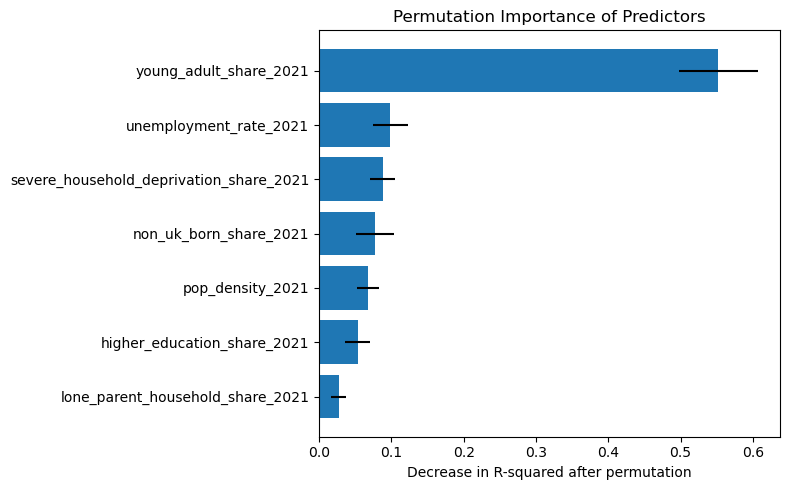

In [20]:
# Plot permutation importance for all predictors
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = perm_df.head(10).iloc[::-1]
ax.barh(
    plot_df['feature'],
    plot_df['importance_mean'],
    xerr=plot_df['importance_std']
)
ax.set_xlabel('Decrease in R-squared after permutation')
ax.set_title("Permutation Importance of Predictors")
plt.tight_layout()
plt.show()

#### 4.4.2 SHAP interpretation

SHAP values were used to examine the direction of each predictor’s effect on model predictions.

In [21]:
# To make SHAP faster, sample the test data
X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf_model)
# Calculate SHAP values
shap_values = explainer(X_test_sample)
#shap.plots.beeswarm(shap_values, max_display=10)

## 5. Results

[[ go back to the top ]](#Table-of-contents)

In [22]:
# Combine Linear Regression and Random Forest results
model_results = pd.concat([lr_results, rf_results], ignore_index=True)
model_results

,Model,Dataset,R-squared,MAE,RMSE
0,Linear Regression,Training,0.467,0.250,0.349
1,Linear Regression,Testing,0.478,0.231,0.292
2,Random Forest,Training,0.693,0.189,0.265
3,Random Forest,Testing,0.528,0.219,0.277


The results show that, in the Random Forest model, the selected socio-economic and demographic indicators explained part of the variation in ward-level crime rates in London. The testing R² was 0.528, meaning that the model explained approximately 52.8% of the variation in crime rates in the test set. The testing MAE and RMSE indicate that prediction errors remained. Compared with the Linear Regression baseline, the Random Forest model performed slightly better on the test set. However, the training R² of the Random Forest model was 0.693, which was higher than the testing R², indicating that it performed better on the training data than on unseen data.

The permutation importance results show that the proportion of residents aged 20–39 was the most important predictor. After this variable was permuted, the model’s R² decreased by an average of 0.552, which was clearly higher than the other variables. Unemployment rate and severe household deprivation were the next important predictors, followed by non-UK-born population share and population density. Higher education share and lone-parent household share had relatively weaker importance.

In [23]:
perm_df.head(10)

,feature,importance_mean,importance_std
1,young_adult_share_2021,0.552319,0.054819
2,unemployment_rate_2021,0.098485,0.024615
6,severe_household_deprivation_share_2021,0.087750,0.017510
4,non_uk_born_share_2021,0.077369,0.026197
0,pop_density_2021,0.067633,0.015504
3,higher_education_share_2021,0.053570,0.017178
5,lone_parent_household_share_2021,0.027127,0.010647


 The SHAP results support these findings. A higher young adult share generally increased the predicted crime rate. Higher unemployment and severe household deprivation also tended to increase predicted crime rates, but their effects were weaker than that of young adult share. Overall, the results suggest that the Random Forest model relied most strongly on demographic structure, especially young adult share, while socio-economic disadvantage indicators played a secondary role.

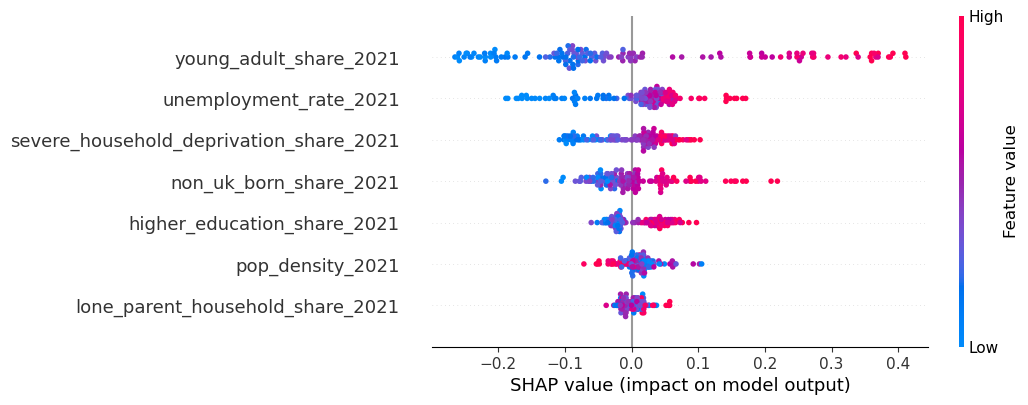

In [24]:
shap.plots.beeswarm(shap_values, max_display=10)

## 6. Discussion

[[ go back to the top ]](#Table-of-contents)

These results suggest that socio-economic and demographic indicators have some predictive power forward-level crime rates in London. The random forest model explains only a partial spatial variation in crime rates, suggesting that crime rates may also be influenced by other factors, such as land use, commercial activity, transportation accessibility, and the movement of tourists and commuters (Malleson and Andresen, 2016). Since this study calculates crime rates based on the resident population, crime rates in some central wards may be influenced by non-resident populations.

According to the model’s interpretation results, the proportion of the youth population is the most significant predictor. This is consistent with existing criminological research, which indicates that criminal activity is typically more concentrated during adolescence and young adulthood and declines with age (Youth Endowment Fund, 2024). However, these findings in this study are based on a ward-level predictive model, it cannot be concluded that the youth population directly causes an increase in crime rates. Specifically, wards with a higher proportion of young people may also have higher population mobility and greater commercial or social activity, which could be associated with higher recorded crime rates. Unemployment rates and high levels of severe household poverty also play a role, indicating that socioeconomic disadvantage remains linked to fluctuations in crime rates.


## 7. Conclusion

[[ go back to the top ]](#Table-of-contents)

Overall, this study suggests that socioeconomic and demographic indicators can predict crime rates in London’s constituencies to some extent, but the predictive power is limited. The Random Forest model explained 52.8% of the variation in log-transformed crime rates in the test set. Young adult share was the strongest predictor, followed by unemployment rate and severe household deprivation. However, the findings should be interpreted cautiously because the improvement over Linear Regression was modest, some predictors were correlated, and the analysis cannot prove causality. Future research could include land use, transport accessibility and daytime population.

## 8. References

[[ go back to the top ]](#Table-of-contents)

Ashby, M., Bal, M.G., Croci, G., Fuller, A., Mantl, N. and Youngsub, L. (2022) Benchmarking crime in London against other global cities. London: Centre for Global City Policing. Available at: https://discovery.ucl.ac.uk/id/eprint/10183479/

Cheng, T. and Williams, D. (2012). SPACE-TIME ANALYSIS OF CRIME PATTERNS IN CENTRAL LONDON. ISPRS - International Archives of the Photogrammetry, Remote Sensing and Spatial Information Sciences, XXXIX-B2, pp.47–52. doi:https://doi.org/10.5194/isprsarchives-xxxix-b2-47-2012.

CrimeRate (2022). Greater London Crime Statistics. Available at: https://crimerate.co.uk/london.

Hjalmarsson, R., Machin, S. and Pinotti, P. (2024) Crime and the labor market. CEP Discussion Paper No. 2044. London: Centre for Economic Performance, London School of Economics and Political Science. Available at: https://researchonline.lse.ac.uk/id/eprint/126746/

Malleson, N. and Andresen, M.A. (2016). Exploring the impact of ambient population measures on London crime hotspots. Journal of Criminal Justice, 46, pp.52–63. doi:https://doi.org/10.1016/j.jcrimjus.2016.03.002.

Pramsten, E. (2025) The Relationship Between Socioeconomic Factors and Crime: Exploring the Associations Between Socioeconomic Features and Reported Crime Rates Using Machine Learning Algorithms. Available at: https://urn.kb.se/resolve?urn=urn:nbn:se:uu:diva-563587

Tarling, R. and Dennis, R. (2016). Socio-Economic Determinants of Crime Rates: Modelling Local Area Police-Recorded Crime. The Howard Journal of Crime and Justice, 55(1-2), pp.207–225. doi:https://doi.org/10.1111/hojo.12157.

Youth Endowment Fund (2024) Key facts about violence: violent offending rates tend to peak in late adolescence or early adulthood. Available at: https://youthendowmentfund.org.uk/reports/key-facts-about-violence/6-violent-offending-rates-tend-to-peak-in-late-adolescence-or-early-adulthood/

Zhou Y, Wang F, Zhou S. The Spatial Patterns of the Crime Rate in London and Its Socio-Economic Influence Factors. Social Sciences. 2023; 12(6):340. https://doi.org/10.3390/socsci12060340

## 9. Appendix

GitHub repository and reproducibility

The complete project materials are available in the GitHub repository: [CASA0006-coursework](https://github.com/Iriszhew/CASA0006-coursework).

The full analysis code is provided in the [`CW_code.ipynb` notebook](https://github.com/Iriszhew/CASA0006-coursework/blob/main/CW_code.ipynb). 

The complete data preparation workflow is provided in the [`data_preparation.ipynb` notebook](https://github.com/Iriszhew/CASA0006-coursework/blob/main/data_preparation.ipynb). 

All raw and processed datasets used in the analysis are also stored in the same repository.